<a href="https://colab.research.google.com/github/NITYA1J/DSA495/blob/main/DSA459_HW_W2_Supervised_ML_Bank_Marketing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# DSA 459-005 — Week 2 Homework: Supervised Machine Learning with Mixed Data
## Scenario: Bank Marketing Prediction

### Your role
Imagine you are a **junior data scientist at a bank**.

The bank contacts customers to offer a term deposit. Your team wants to build a machine-learning model that predicts whether a customer is likely to subscribe.

This homework focuses on the core workflow:

**Mixed numeric + categorical data → encode → train → validate → compare → test → evaluate**

### Why this dataset?
The **UCI Bank Marketing** dataset is public and contains both:

- **numeric variables** such as age and account balance;
- **categorical/string variables** such as job, marital status, education, housing loan, and contact type.

That makes it a useful bridge to later parts of this course. Today, we convert categories into numbers with **one-hot encoding**. Later, when we work with LLMs, text will be converted into **tokens and embeddings** instead.

### What to submit
Share **one completed Colab notebook** to me (xwu@ncsu.edu) containing:

1. your code and output;
2. your model comparison;
3. your plots;
4. the short reflection at the end.

This is intended to be a **light homework assignment**. Some of the code is already provided.

Each step title indicates the type of task in that block: **E** (Review and Explore) or **W** (Write Your Code).

**E** — Review and Explore: The existing code is complete and should run as written. Feel free to modify it, experiment with it, and explore the results. In some cases, you may need to review or explore this code in order to answer the assignment questions.

**W** — Write Your Code: Write the code needed to complete the requirements for that step. Please follow the specified variable, function, or class names when provided, since they may be used in later steps.

**Expected time: about 30–45 minutes.**



## Step 1 — Load the public dataset **(E)**

We will download the dataset directly from the **UCI Machine Learning Repository** using its Python package.

The target is:

- `0` = customer did **not** subscribe
- `1` = customer **did** subscribe

To keep the homework fast, we will use a reproducible sample of 6,000 rows.


In [41]:

!pip install -q ucimlrepo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.base import clone

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

RANDOM_STATE = 421

bank = fetch_ucirepo(id=222)

X_full = bank.data.features.copy()
y_full = bank.data.targets.iloc[:, 0].astype(str).str.lower().map(
    {"no": 0, "yes": 1}
)

df = X_full.copy()
df["target"] = y_full

# Keep the homework quick enough for Colab.
df = df.sample(n=6000, random_state=RANDOM_STATE)

X = df.drop(columns="target")
y = df["target"].astype(int)

print("Dataset shape:", X.shape)
display(X.head())


Dataset shape: (6000, 16)


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome
31626,33,technician,single,tertiary,no,127,yes,no,cellular,6,apr,583,2,222,17,failure
39955,32,self-employed,married,secondary,no,409,no,no,cellular,3,jun,115,2,86,2,success
11770,57,technician,married,secondary,no,0,no,no,NaN,20,jun,45,4,-1,0,NaN
134,28,unemployed,single,tertiary,no,0,yes,no,NaN,5,may,125,2,-1,0,NaN
10648,59,blue-collar,married,primary,no,416,no,no,NaN,16,jun,92,3,-1,0,NaN



## Step 2 — Look at the mixed input variables (**E**)

For this homework, we are **not repeating the full data-quality audit from class**.

Instead, notice that the predictors contain both numbers and strings.

### Your task
Run the cell below and identify:

- at least **two numeric variables**;
- at least **two categorical/string variables**.


In [42]:

print("Data types:")
display(X.dtypes.to_frame("dtype"))

numeric_columns = X.select_dtypes(include=np.number).columns.tolist()
categorical_columns = [c for c in X.columns if c not in numeric_columns]

print("\nNumeric variables:")
print(numeric_columns)

print("\nCategorical variables:")
print(categorical_columns)


Data types:


,dtype
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day_of_week,int64



Numeric variables:
['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous']

Categorical variables:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']



### One real-world modeling decision: avoid leakage (**E**)

The UCI dataset documentation notes that **call duration** is only known after the marketing call has occurred.

If our goal is to predict **before making the call**, using this variable would give the model information that would not yet exist in production.

We therefore remove it.

This is called avoiding **data leakage**.


In [43]:

if "duration" in X.columns:
    X = X.drop(columns=["duration"])

print("Number of model input variables:", X.shape[1])


Number of model input variables: 15



## Step 3 — Check the target balance (**E**)

Before training a classifier, look at how many customers subscribed.

This matters because a model can appear accurate simply by predicting the majority class.


,count
No subscription (0),5300
Subscription (1),700


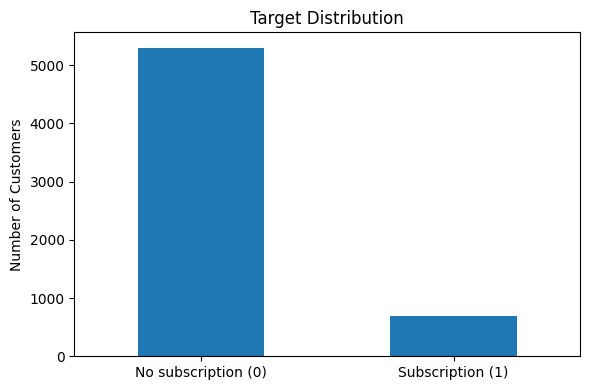

In [44]:

target_counts = y.value_counts().sort_index()
target_counts.index = ["No subscription (0)", "Subscription (1)"]

display(target_counts.to_frame("count"))

plt.figure(figsize=(6, 4))
target_counts.plot(kind="bar")
plt.title("Target Distribution")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



## Step 4 — Create training, validation, and test sets (**W**)

We use approximately:

- **60% training** — fit the model;
- **20% validation** — compare candidate models;
- **20% test** — final evaluation.

The test set stays untouched until after we choose our model.

This same idea becomes important later when we evaluate neural networks and LLMs.

Hint: 1. Data frame with input feature is X, target is y
      2. call train_test_split() twice to achieve the desired partitions named
      X_trainval, X_test, y_trainval, y_test, X_train, X_val, y_train, y_val


In [46]:
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.25, random_state=RANDOM_STATE)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (3600, 15)
y_train shape: (3600,)
X_val shape: (1200, 15)
y_val shape: (1200,)
X_test shape: (1200, 15)
y_test shape: (1200,)



## Step 5 — Convert categorical strings into model inputs (**W**)

Most traditional machine-learning algorithms cannot directly use strings such as:

`"technician"`, `"married"`, `"yes"`, `"cellular"`

We will:

- scale numeric variables;
- convert categorical variables with **one-hot encoding**.

### Connection to LLMs
Traditional ML often converts categories into indicator columns.

LLMs handle strings differently:

**text → tokens → embeddings → model**

The representation changes, but the same basic question remains:

> **How do we turn real-world information into a representation the model can learn from?**

Hint:
1.Create a OneHotEncoder() instance.
2.Put it inside a Pipeline for the categorical features, along with any needed imputation.
3.Use ColumnTransformer to apply the categorical pipeline to categorical_features and the numerical pipeline to numeric_features, name the ColumnTransformer instance preprocess.

In [47]:
 numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
 categorical_features = [c for c in X_train.columns if c not in numeric_features]
 print("Numeric features:", numeric_features)
 print("\nCategorical features:", categorical_features)

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = [c for c in X_train.columns if c not in numeric_features]

# Numeric Features: Impute missing values with the mean and scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Categorical Features: Impute missing values with a constant and one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a ColumnTransformer to apply different transformations to different columns
preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("Preprocessing pipeline 'preprocess' created.")

Numeric features: ['age', 'balance', 'day_of_week', 'campaign', 'pdays', 'previous']

Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Preprocessing pipeline 'preprocess' created.



# Step 6 — Choose TWO candidate models (**E**)

You may choose **any two** models from this list:

1. Decision Tree
2. Gradient Boosting
3. SVM
4. Logistic Regression
5. KNN

### Your task
Change `chosen_models` below so it contains the two models you want to compare.

Example:

`chosen_models = ["Logistic Regression", "Gradient Boosting"]`

Do not choose the same model twice.


In [67]:
candidate_estimators = {

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=2,
        random_state=RANDOM_STATE
    ),

    "Logistic Regression": LogisticRegression(
        C=1.0,
        max_iter=2000
    )
}

# TODO: Choose TWO models of your choice.
chosen_models = ["Logistic Regression", "Gradient Boosting"]

assert len(chosen_models) == 2
assert chosen_models[0] != chosen_models[1]
assert all(name in candidate_estimators for name in chosen_models)

models = {}

for name in chosen_models:
    models[name] = Pipeline([
        ("preprocess", clone(preprocess)),
        ("model", clone(candidate_estimators[name]))
    ])

print("You selected:", chosen_models)


You selected: ['Logistic Regression', 'Gradient Boosting']



## Step 7 — Train your two models (**W**)

Training means the model learns from the **training data**.

Later, evaluation asks a different question:

> **How well does the learned model work on data it did not train on?**

Hint:
1.models is a dictionary that contains name as key, model as value
2.call model.fit()


In [68]:
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    print(f"Finished training {name}.")

Training Logistic Regression...
Finished training Logistic Regression.
Training Gradient Boosting...
Finished training Gradient Boosting.



## Step 8 — Compare the models on validation data (**E**)

We will compare:

- **Accuracy**
- **Balanced Accuracy**
- **ROC AUC**
- **PR AUC**

Because the positive class is less common, looking at several metrics gives us more information than accuracy alone.


,Accuracy,Balanced Accuracy,ROC AUC,PR AUC
Model,,,,
Logistic Regression,0.878,0.580,0.736,0.332
Gradient Boosting,0.883,0.568,0.769,0.365


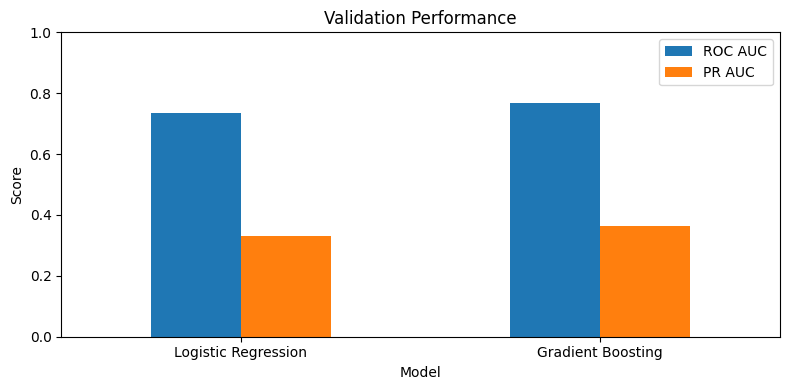

In [69]:

def get_metrics(model, X_part, y_part):
    pred = model.predict(X_part)
    prob = model.predict_proba(X_part)[:, 1]

    return {
        "Accuracy": accuracy_score(y_part, pred),
        "Balanced Accuracy": balanced_accuracy_score(y_part, pred),
        "ROC AUC": roc_auc_score(y_part, prob),
        "PR AUC": average_precision_score(y_part, prob)
    }

rows = []

for name, model in models.items():
    metrics = get_metrics(model, X_val, y_val)
    metrics["Model"] = name
    rows.append(metrics)

validation_results = pd.DataFrame(rows).set_index("Model")

display(validation_results.round(3))

validation_results[["ROC AUC", "PR AUC"]].plot(
    kind="bar",
    figsize=(8, 4)
)
plt.title("Validation Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



## Step 9 — Select one model (**E**)

Use your **validation results** to decide which model you would move forward with.

ROC AUC is a useful overall ranking metric here, but also look at the other metrics.

### Your task
Set `best_model_name` to the model you selected.


In [70]:

# TODO: Replace this with your selected model.
best_model_name = validation_results["ROC AUC"].idxmax()

print("Selected model:", best_model_name)

# Refit the chosen model using both training + validation data.
best_model = Pipeline([
    ("preprocess", clone(preprocess)),
    ("model", clone(candidate_estimators[best_model_name]))
])

best_model.fit(X_trainval, y_trainval)


Selected model: Gradient Boosting


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'balance',
                                                   'day_of_week', 'campaign',
                                                   'pdays', 'previous']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'poutcome'])])),
                ('model',
                 GradientBoostingClassifier(learning_rate=0.05, max_depth=2,
                                            random_state=421))])


# Step 10 — Final test-set evaluation (**W**)

Now — and only now — we use the **test set**.

This gives us a final estimate of how the selected model performs on unseen data.

Using best_model and X_test, generate the predicted class labels and predicted probabilities for the positive class. Store the class predictions in test_pred and the positive-class probabilities in test_prob.

Hint: call best_model.predict() and best_model.predict_proba()


In [71]:
test_pred = best_model.predict(X_test)
test_prob = best_model.predict_proba(X_test)[:, 1]

test_results = pd.Series({
    "Accuracy": accuracy_score(y_test, test_pred),
    "Balanced Accuracy": balanced_accuracy_score(y_test, test_pred),
    "ROC AUC": roc_auc_score(y_test, test_prob),
    "PR AUC": average_precision_score(y_test, test_prob)
}, name="Test Score")

display(test_results.round(3).to_frame())

,Test Score
Accuracy,0.895
Balanced Accuracy,0.559
ROC AUC,0.739
PR AUC,0.343



## Step 11 — Visual model assessment (**E**)

Look at three different views of model performance:

1. Confusion Matrix
2. ROC Curve
3. Precision-Recall Curve


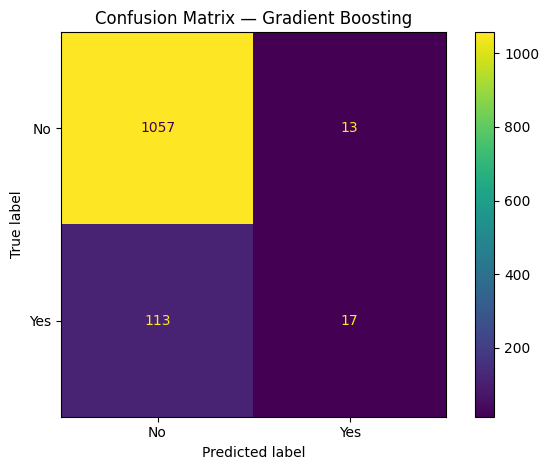

In [72]:

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_pred,
    display_labels=["No", "Yes"]
)

plt.title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.show()


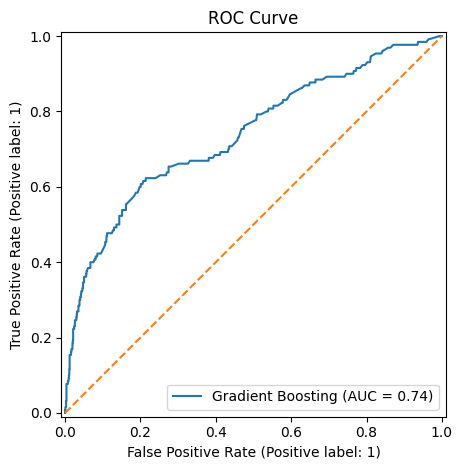

In [73]:

RocCurveDisplay.from_predictions(
    y_test,
    test_prob,
    name=best_model_name
)

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve")
plt.tight_layout()
plt.show()


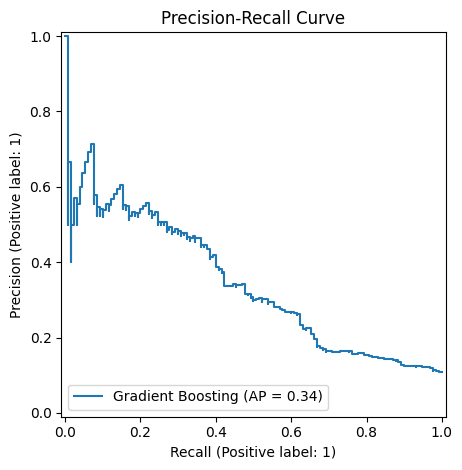

In [74]:

PrecisionRecallDisplay.from_predictions(
    y_test,
    test_prob,
    name=best_model_name
)

plt.title("Precision-Recall Curve")
plt.tight_layout()
plt.show()



# Challenge — Bias and Variance Experiment (optional 10 bonus points)

This challenge is short, but it connects directly to the **bias-variance** discussion from class.

Choose **one model family** below and compare several parameter settings.

Examples:

- Decision Tree: `max_depth = 2, 5, None`
- Gradient Boosting: `max_depth = 1, 2, 4`
- SVM: `C = 0.1, 1, 10`
- Logistic Regression: `C = 0.01, 1, 100`
- KNN: `n_neighbors = 3, 15, 75`

We will compare **training ROC AUC** with **validation ROC AUC**.

### Interpretation
- Poor training **and** validation performance can suggest **high bias / underfitting**.
- Very strong training performance but noticeably weaker validation performance can suggest **high variance / overfitting**.

The train-validation gap is a practical diagnostic, not a formal mathematical bias-variance decomposition.


,C,Train ROC AUC,Validation ROC AUC,Train-Validation Gap
0,0.01,0.747,0.731,0.016
1,1,0.777,0.736,0.041
2,100,0.777,0.732,0.045


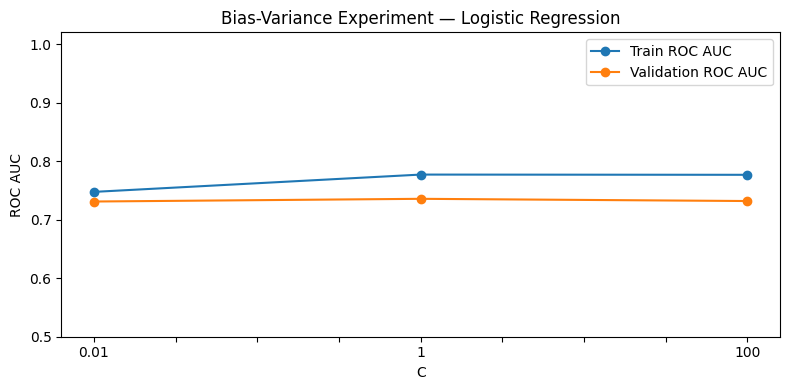

In [77]:

# TODO: Choose one model family for your experiment.
challenge_model = chosen_models[0]

parameter_settings = {
    "Gradient Boosting": ("max_depth", [1, 2, 4]),
    "Logistic Regression": ("C", [0.01, 1, 100]),

}

parameter_name, values = parameter_settings[challenge_model]

challenge_rows = []

for value in values:

    if challenge_model == "Gradient Boosting":
        estimator = GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.05,
            max_depth=value,
            random_state=RANDOM_STATE
        )

    elif challenge_model == "Logistic Regression":
        estimator = LogisticRegression(
            C=value,
            max_iter=2000
        )

    experiment_model = Pipeline([
        ("preprocess", clone(preprocess)),
        ("model", estimator)
    ])

    experiment_model.fit(X_train, y_train)

    train_prob = experiment_model.predict_proba(X_train)[:, 1]
    val_prob = experiment_model.predict_proba(X_val)[:, 1]

    train_auc = roc_auc_score(y_train, train_prob)
    val_auc = roc_auc_score(y_val, val_prob)

    challenge_rows.append({
        parameter_name: str(value),
        "Train ROC AUC": train_auc,
        "Validation ROC AUC": val_auc,
        "Train-Validation Gap": train_auc - val_auc
    })

challenge_results = pd.DataFrame(challenge_rows)

display(challenge_results.round(3))

challenge_results.plot(
    x=parameter_name,
    y=["Train ROC AUC", "Validation ROC AUC"],
    marker="o",
    figsize=(8, 4)
)

plt.title(f"Bias-Variance Experiment — {challenge_model}")
plt.ylabel("ROC AUC")
plt.ylim(0.5, 1.02)
plt.tight_layout()
plt.show()



# Short Report

Answer each question in about **1–3 sentences**.  
Type your answers directly into this notebook.

### 1. Model choice
Which two candidate models did you choose? Which performed better on the validation set, and what evidence supports your answer?

### 2. Categorical data
Give one example of a categorical/string variable from this dataset. Why did we need to encode it before using it with these traditional ML models?

### 3. Training vs. evaluation
In your own words, what is the difference between **training a model** and **evaluating a model**?

### 4. Why keep a test set?
Why did we use validation data to choose the model instead of repeatedly looking at the test set?

### 5. Model assessment
Look at your confusion matrix, ROC curve, and PR curve. What is one thing you learned about your model that would not be obvious from accuracy alone?

### 6. Bias-variance challenge (optional)
From your parameter experiment:
- Which setting appears to have the **highest bias / strongest underfitting tendency**?
- Which setting appears to have the **highest variance / strongest overfitting tendency**?

Explain using the training and validation results.

### 7. Connection to LLMs
Name one idea from this homework that you think will still matter when we later build or evaluate LLM systems.

> Keep the answers short. The goal is to show that you understand what you did and why.



## Write your answers here

**1. Model choice:**  
Your answer: I chose Logistic Regression and Gradient Boosting. Gradient Boosting performed better on the validation set, as evidenced by higher ROC AUC and PR AUC scores.

**2. Categorical data:**  
Your answer: An example is `job` (or `marital`, `education`). Traditional ML algorithms rely on numerical matrix operations, which requirestext strings into numbers  via one-hot encoding before training.

**3. Training vs. evaluation:**  
Your answer: Training is the process where a model learns underlying patterns and updates its internal weights using training data. Evaluation measures how well that trained model generalizes to unseen data using performance metrics like ROC AUC or accuracy.  

**4. Why keep a test set?**  
Your answer: Using validation data for model selection prevents the model from implicitly adapting to the test set, avoiding data leakage. Preserving a separate test set until the final step ensures an unbiased measurement of real-world generalization performance.

**5. Model assessment:**  
Your answer: Because of class imbalance, high accuracy can be misleading. The confusion matrix and PR curve revealed that the model yields notable false negatives on the minority class, revealing a weakness in identifying actual subscribers that accuracy alone hides.

**6. Bias-variance challenge (optional):**  
Your answer: Low-capacity settings (e.g., `max_depth = 1` or` C = 0.01`) show the highest bias/underfitting, resulting in low ROC AUC across both training and validation sets. High-capacity settings (e.g.,` max_depth = 4` or `C = 100`) show the highest variance/overfitting, achieving strong training ROC AUC but widening the gap with validation performance.

**7. Connection to LLMs:**  
Your answer: Encoding categorical strings into numeric vectors directly parallels how LLMs convert text into tokens and embeddings. Furthermore, strict test-set isolation remains essential for LLM evaluation to verify genuine generalization rather than memorization of training data.



# Main Takeaway

You have now practiced a compact version of a real supervised-learning workflow:

**Represent data → train → validate → compare → test → evaluate → explain**

Later in the course:

- categorical strings will become **tokens and embeddings**;
- traditional classifiers will become **neural networks and LLMs**;
- ROC and PR may be replaced or supplemented by **LLM-specific evaluation metrics**.

But the scientific mindset remains:

> **Build on training data, make decisions with validation data, test honestly, examine failures, and explain what the model is doing.**
